# Loan Prediction Dataset - Exploratory Data Analysis

## Objective

The objective of this notebook is to understand the Loan Prediction dataset and identify preprocessing decisions required before feature engineering and machine learning.

This notebook focuses on:

- Data understanding
- Missing value analysis
- Feature distributions
- Relationships with target variable
- Outlier detection
- Correlation analysis
- Preprocessing recommendations

No feature engineering or model training is performed in this notebook.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/train_u6lujuX_CVtuZ9i.csv')

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


# Dataset Overview

The Loan Prediction dataset contains customers information and loan outcomes.

Target Variable:

- Loan_status

Prediction Goal:

Predict whether a get's a loan or not.

**Data inspection**

In [ ]:
df.shape

(614, 13)

Dataset contains 614 rows and 13 columns.

In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Dataset contains both categorical and numerical features.

Some columns contain missing values and require preprocessing.

In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


ApplicantIncome and LoanAmount contain large ranges,
indicating possible outliers.

In [ ]:
df.duplicated().sum()

np.int64(0)

Dataset contains duplicate records which should be removed.

**Missing Value Analysis**

In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
(df.isnull().sum()/len(df))*100

,0
Loan_ID,0.000000
Gender,2.117264
Married,0.488599
Dependents,2.442997
Education,0.000000
Self_Employed,5.211726
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,3.583062
Loan_Amount_Term,2.280130


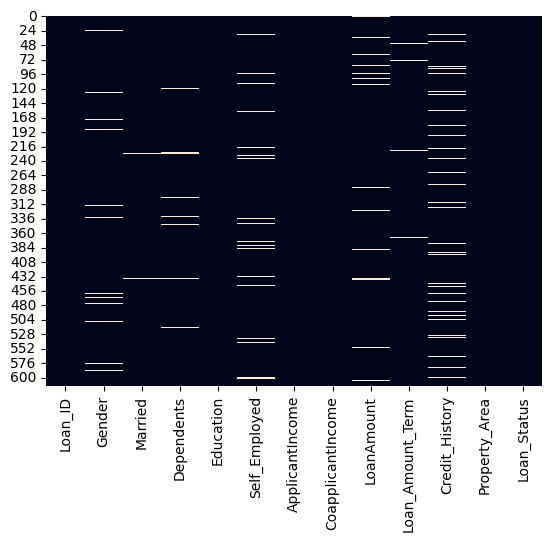

In [ ]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

**Observation:**

LoanAmount, Credit_History and Self_Employed contain missing values.

**Decision:**

Categorical columns will use mode imputation.
Numerical columns will use median imputation.

**Data Type Analysis**

In [ ]:
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


**Observation:**

Dependents is stored as object datatype due to the presence of '3+' values.

**decision:**

Dependents column requires cleaning before model building.

In [ ]:
unique = {}
for col in df.columns:
  unique[col] = df[col].nunique()

In [ ]:
unique

{'Loan_ID': 614,
 'Gender': 2,
 'Married': 2,
 'Dependents': 4,
 'Education': 2,
 'Self_Employed': 2,
 'ApplicantIncome': 505,
 'CoapplicantIncome': 287,
 'LoanAmount': 203,
 'Loan_Amount_Term': 10,
 'Credit_History': 2,
 'Property_Area': 3,
 'Loan_Status': 2}

In [ ]:
cat_cols = df.select_dtypes(
    include=['object']
).columns.tolist()

In [ ]:
for col in cat_cols:
  df[col] = df[col].astype('category')

In [ ]:
df['Credit_History'] = df['Credit_History'].astype('category')

In [ ]:
df.dtypes

,0
Loan_ID,category
Gender,category
Married,category
Dependents,category
Education,category
Self_Employed,category
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


<Axes: xlabel='Loan_Status', ylabel='count'>

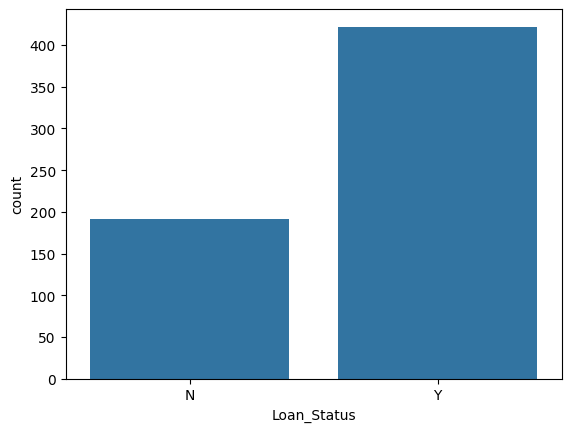

In [ ]:
sns.countplot(data = df,x='Loan_Status')

In [ ]:
df['Loan_Status'].value_counts(normalize = True)

,proportion
Loan_Status,
Y,0.687296
N,0.312704


**Observation:**

Most loans are approved compared to rejected loans.

**Decision:**

Dataset is slightly imbalanced.
Stratified splitting may be required during model training.

# **Univariate analysis**

**Categorical analysis**

<Axes: xlabel='Gender', ylabel='count'>

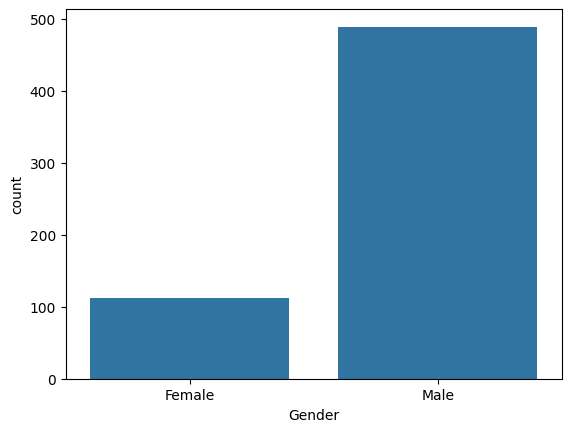

In [ ]:
sns.countplot(data = df,x = 'Gender')

In [ ]:
df['Gender'].value_counts(normalize = True)

,proportion
Gender,
Male,0.813644
Female,0.186356


**Observation:**

Male applicants are significantly higher than female applicants.

**Business Insight:**

The dataset reflects higher male participation in loan applications.

**Decision:**


This feature is categorical so we can concider it to encode it before modeling

<Axes: xlabel='Married', ylabel='count'>

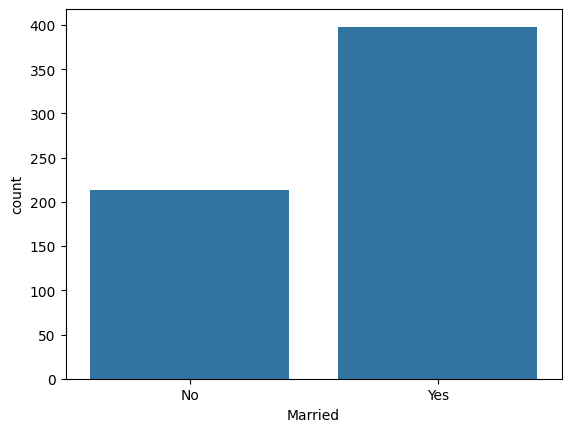

In [ ]:
sns.countplot(data = df,x = 'Married')

In [ ]:
df['Married'].value_counts(normalize = True)

,proportion
Married,
Yes,0.651391
No,0.348609


**Observation:**

Married feature show that married customers take loan over 65% and unmarried about 35%.

**Decision:**

This feature is categorical so we can concider it to encode it before modeling

<Axes: xlabel='Dependents', ylabel='count'>

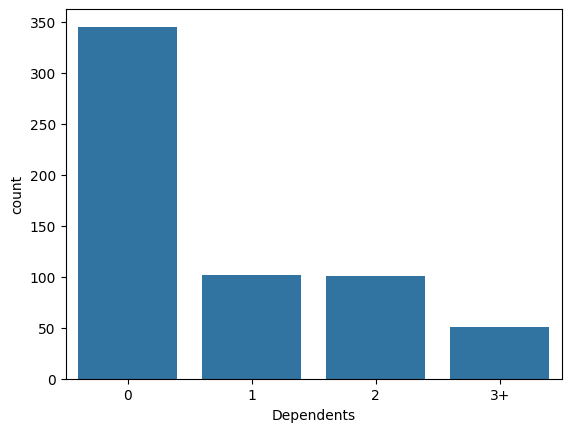

In [ ]:
sns.countplot(data = df,x = 'Dependents')

In [ ]:
df['Dependents'].value_counts(normalize = True)

,proportion
Dependents,
0,0.575960
1,0.170284
2,0.168614
3+,0.085142


**Observation:**

Most applicants have fewer dependents.

**Business Insight:**

Lower dependent count may indicate lower financial burden.

**Decision:**

This feature is categorical so we can concider it to encode it before modeling. fearther more analysis is require

<Axes: xlabel='Education', ylabel='count'>

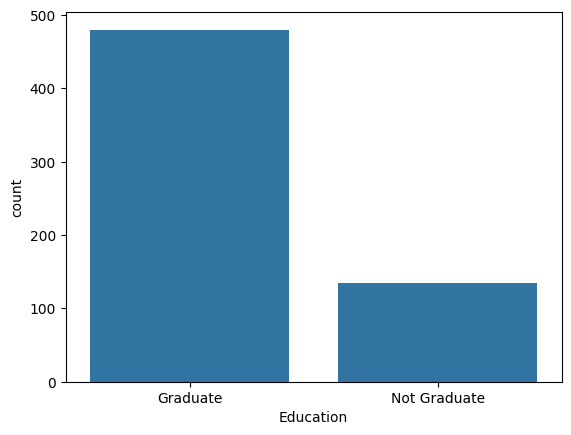

In [ ]:
sns.countplot(data = df,x = 'Education')

In [ ]:
df['Education'].value_counts(normalize = True)

,proportion
Education,
Graduate,0.781759
Not Graduate,0.218241


**Observation:**

Graduate applicants are more common than non-graduates.

**Decision:**

This feature is categorical so we can concider it to encode it before modeling. fearther more analysis is requirev

<Axes: xlabel='Self_Employed', ylabel='count'>

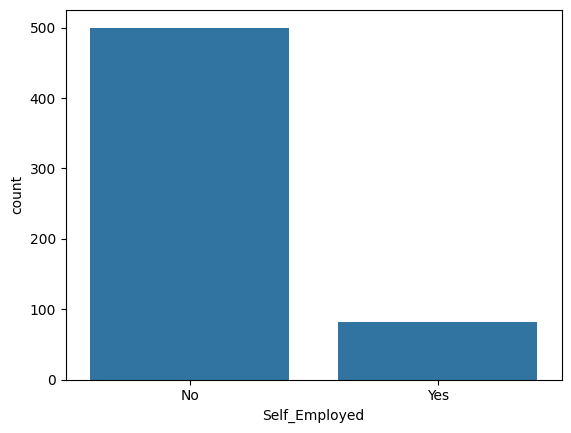

In [ ]:
sns.countplot(data = df,x = 'Self_Employed')

In [ ]:
df['Self_Employed'].value_counts(normalize = True)

,proportion
Self_Employed,
No,0.859107
Yes,0.140893


**Observation:**

Most applicants are not self-employed.

**Decision:**

This feature is categorical so we can concider it to encode it before modeling. fearther more analysis is requirev

<Axes: xlabel='Property_Area', ylabel='count'>

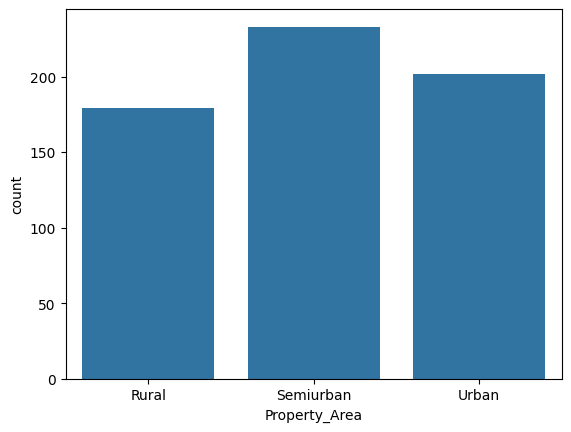

In [ ]:
sns.countplot(data = df,x = 'Property_Area')

In [ ]:
df['Property_Area'].value_counts(normalize = True)

,proportion
Property_Area,
Semiurban,0.379479
Urban,0.328990
Rural,0.291531


**Observation:**

Semiurban applicants appear slightly higher than other regions.

**Decision:**

This feature is categorical so we can concider it to encode it before modeling. fearther more analysis is require

<Axes: xlabel='Credit_History', ylabel='count'>

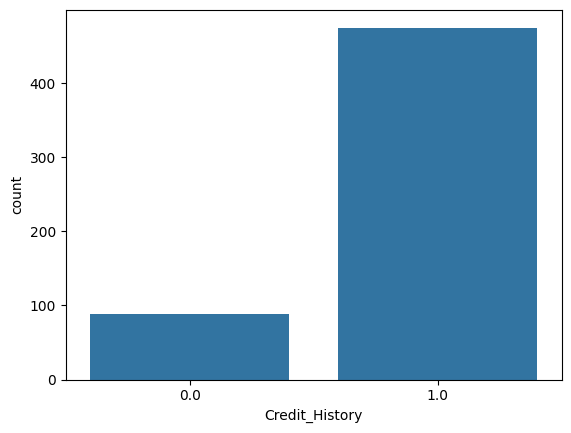

In [ ]:
sns.countplot(data = df,x = 'Credit_History')

In [ ]:
df['Credit_History'].value_counts(normalize = True)

,proportion
Credit_History,
1.0,0.842199
0.0,0.157801


**Observation:**

Most applicants have a good credit history.

**Business Insight:**

Financial institutions generally prefer applicants with strong repayment records.

**Decision:**

This feature is categorical so we can concider it to encode it before modeling. fearther more analysis is required

**Numaric feature analysis**

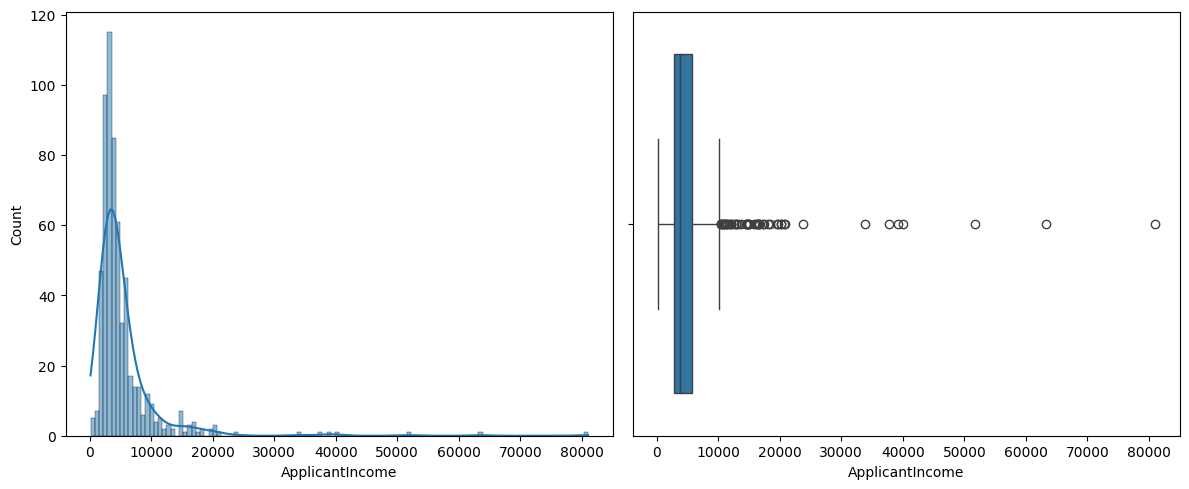

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data = df,x = 'ApplicantIncome',kde = True)
plt.subplot(1,2,2)
sns.boxplot(data = df,x = 'ApplicantIncome')
plt.tight_layout()
plt.show()

**Observation:**

ApplicantIncome is highly right-skewed and contains multiple extreme outliers.

**Decision:**

Log transformation may improve distribution symmetry.

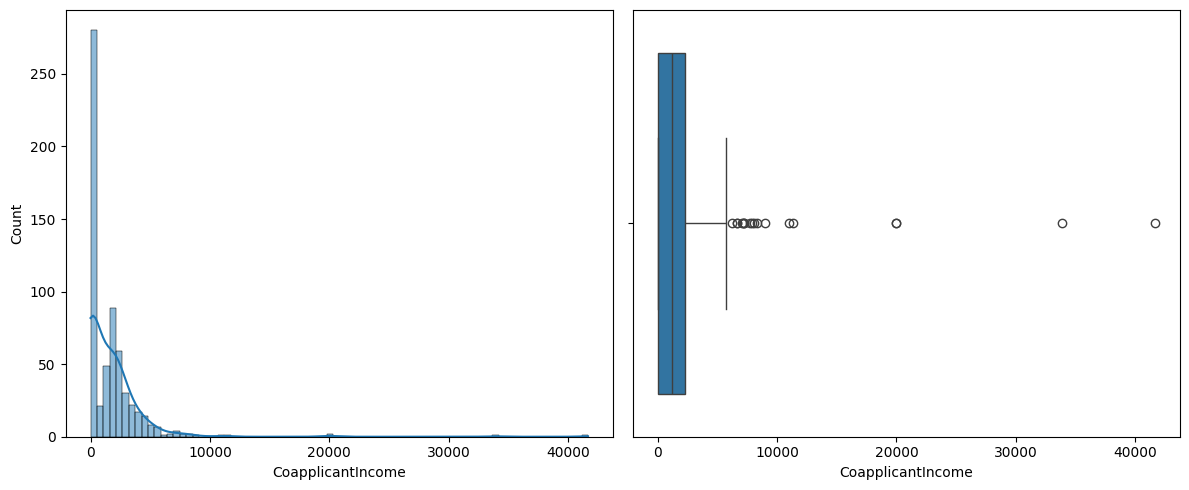

In [ ]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data = df,x = 'CoapplicantIncome',kde = True)
plt.subplot(1,2,2)
sns.boxplot(data = df,x = 'CoapplicantIncome')
plt.tight_layout()
plt.show()

**Observarion:**

Most co-applicant income values are concentrated near zero with several outliers.


**Decision:**

Consider applying log transformation to reduce skewness.

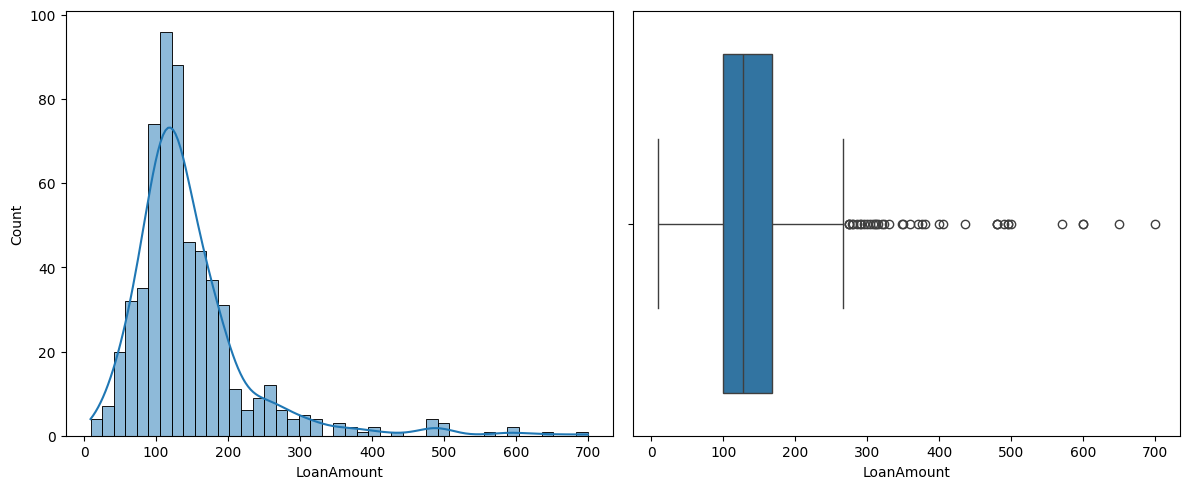

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data = df,x = 'LoanAmount',kde = True)
plt.subplot(1,2,2)
sns.boxplot(data = df,x = 'LoanAmount')
plt.tight_layout()
plt.show()

**Observation :**

LoanAmount contains moderate skewness and some high-value outliers.

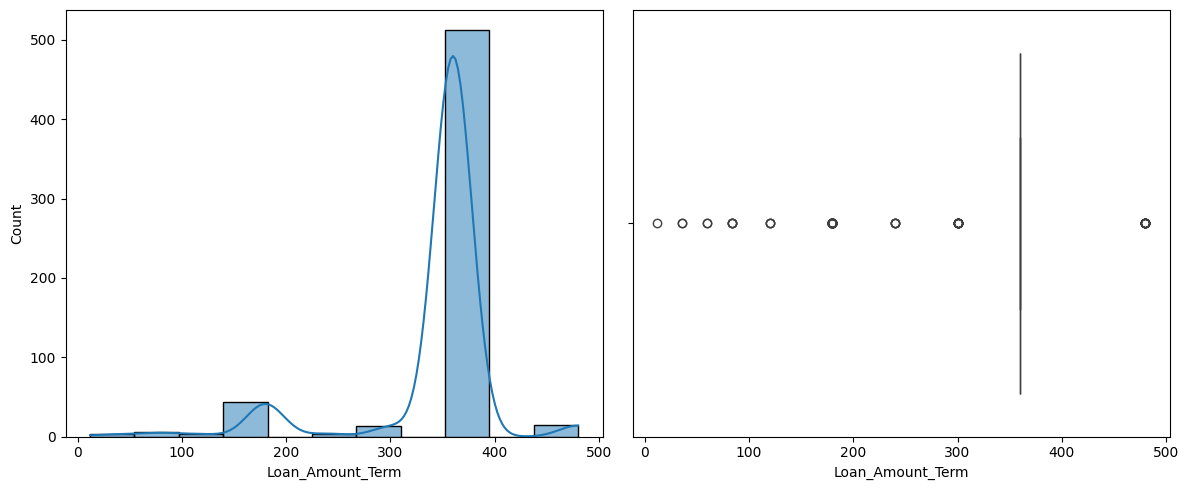

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(data = df,x = 'Loan_Amount_Term',kde = True)
plt.subplot(1,2,2)
sns.boxplot(data = df,x = 'Loan_Amount_Term')
plt.tight_layout()
plt.show()

**Observation:**

Most loans have repayment terms around 360 months.

# **Bivariate Analysis**

<Axes: xlabel='Gender', ylabel='count'>

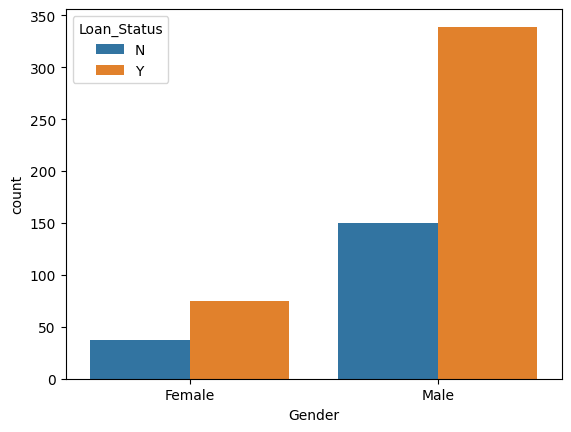

In [ ]:
sns.countplot(data = df,x = 'Gender',hue = 'Loan_Status')

In [ ]:
df.groupby('Gender')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/662222114.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')['Loan_Status'].value_counts(normalize=True)


Gender  Loan_Status
Female  Y              0.669643
        N              0.330357
Male    Y              0.693252
        N              0.306748
Name: proportion, dtype: float64


### Observation
`Gender` shows relationship with `Loan_Status`.

### Business Insight
`Gender` may affect approval trends and financial risk assessment.

### Decision
`Gender` should be evaluated as a predictive feature during model building.


<Axes: xlabel='Married', ylabel='count'>

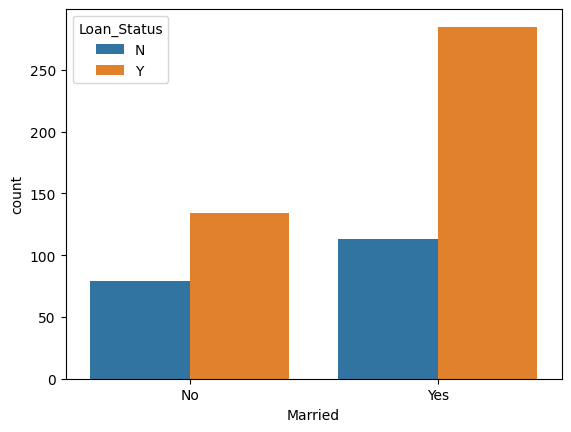

In [ ]:
sns.countplot(data = df,x = 'Married',hue = 'Loan_Status')

In [ ]:
df.groupby('Married')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/548234794.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Married')['Loan_Status'].value_counts(normalize=True)


Married  Loan_Status
No       Y              0.629108
         N              0.370892
Yes      Y              0.716080
         N              0.283920
Name: proportion, dtype: float64

**Observation:**

Married customesrs approvel rate is higher than unmarried

**Business Insight:**

may affect approval trends and financial risk assessment.

**Decision:**

consider encoding feature before model training

<Axes: xlabel='Dependents', ylabel='count'>

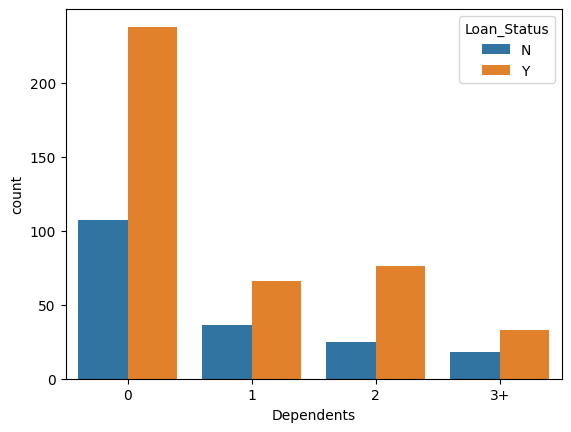

In [ ]:
sns.countplot(data = df,x = 'Dependents',hue = 'Loan_Status')

In [ ]:
df.groupby('Dependents')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/2290027237.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Dependents')['Loan_Status'].value_counts(normalize=True)


Dependents  Loan_Status
0           Y              0.689855
            N              0.310145
1           Y              0.647059
            N              0.352941
2           Y              0.752475
            N              0.247525
3+          Y              0.647059
            N              0.352941
Name: proportion, dtype: float64

**Observation:**

Customers with 0 and 2 dependency have high rate of loan approval

**Decision:**

consider encoding feature before model training

<Axes: xlabel='Education', ylabel='count'>

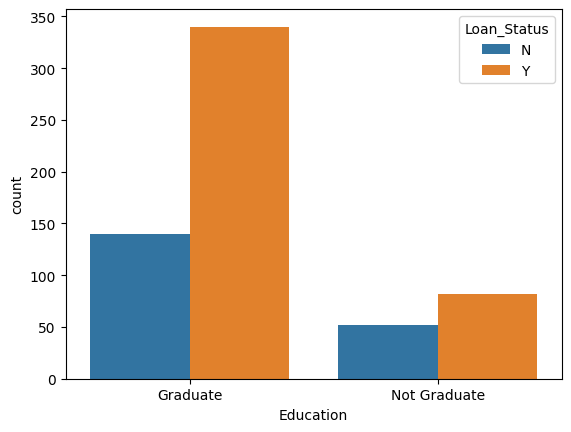

In [ ]:
sns.countplot(data = df,x = 'Education',hue = 'Loan_Status')

In [ ]:
df.groupby('Education')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/3319252447.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Education')['Loan_Status'].value_counts(normalize=True)


Education     Loan_Status
Graduate      Y              0.708333
              N              0.291667
Not Graduate  Y              0.611940
              N              0.388060
Name: proportion, dtype: float64


### Observation
`Education` shows relationship with `Loan_Status`.

### Business Insight
`Education` may affect approval trends and financial risk assessment.

### Decision
`Education` should be evaluated as a predictive feature during model building.


<Axes: xlabel='Self_Employed', ylabel='count'>

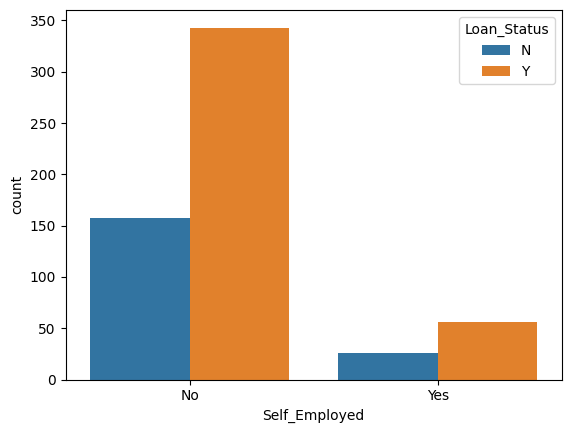

In [ ]:
sns.countplot(data = df,x = 'Self_Employed',hue = 'Loan_Status')

In [ ]:
df.groupby('Self_Employed')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/2623783157.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Self_Employed')['Loan_Status'].value_counts(normalize=True)


Self_Employed  Loan_Status
No             Y              0.686000
               N              0.314000
Yes            Y              0.682927
               N              0.317073
Name: proportion, dtype: float64

<Axes: xlabel='Property_Area', ylabel='count'>

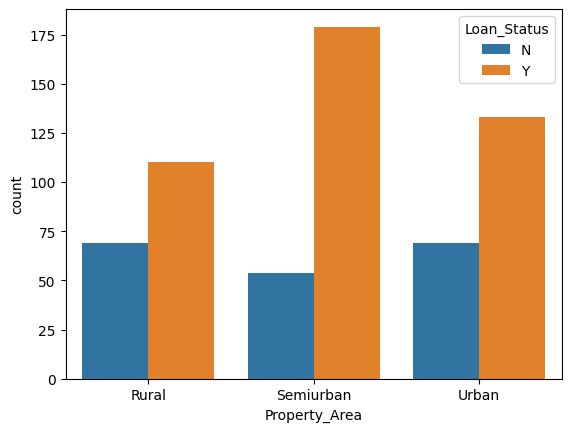

In [ ]:
sns.countplot(data = df,x = 'Property_Area',hue = 'Loan_Status')

In [ ]:
df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/2147387017.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Property_Area')['Loan_Status'].value_counts(normalize=True)


Property_Area  Loan_Status
Rural          Y              0.614525
               N              0.385475
Semiurban      Y              0.768240
               N              0.231760
Urban          Y              0.658416
               N              0.341584
Name: proportion, dtype: float64


### Observation
`Property_Area` shows relationship with `Loan_Status`.

### Business Insight
`Property_Area` may affect approval trends and financial risk assessment.

### Decision
`Property_Area` should be evaluated as a predictive feature during model building.


<Axes: xlabel='Credit_History', ylabel='count'>

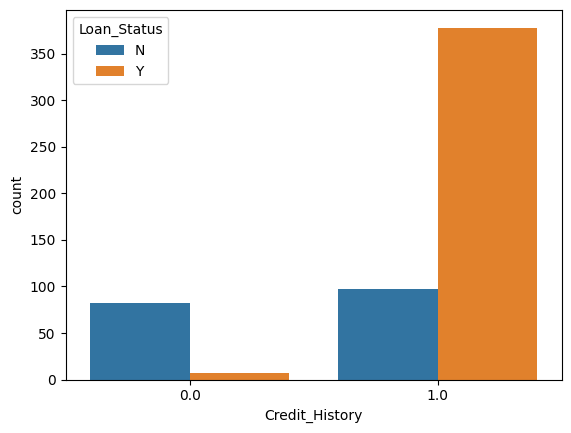

In [ ]:
sns.countplot(data = df,x = 'Credit_History',hue = 'Loan_Status')

In [ ]:
df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True)

/tmp/ipykernel_2712/980620136.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Credit_History')['Loan_Status'].value_counts(normalize=True)


Credit_History  Loan_Status
0.0             N              0.921348
                Y              0.078652
1.0             Y              0.795789
                N              0.204211
Name: proportion, dtype: float64


### Observation
Customers with bad credit history there loan is maximum chances to reject it show strong relationship with loan status.

### Business Insight
`Credit_History` may affect approval trends and financial risk assessment.

### Decision
`Credit_History` should be evaluated as a predictive feature during model building.


<Axes: xlabel='Loan_Status', ylabel='ApplicantIncome'>

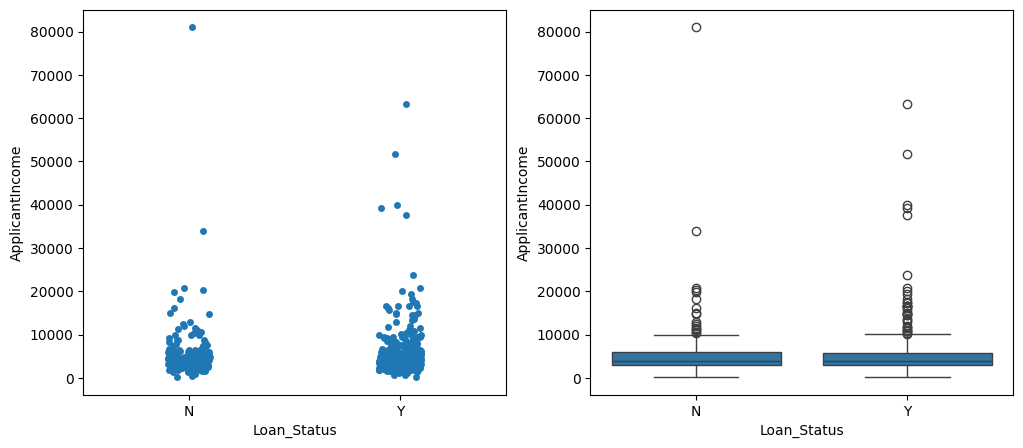

In [ ]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
sns.stripplot(data=df, x='Loan_Status', y='ApplicantIncome')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Loan_Status', y='ApplicantIncome')

**Observation:**

Customers with income over 5k is most likly to approve there loan

**Decision:**

Consider scaling and log transformation before modeling

<Axes: xlabel='Loan_Status', ylabel='CoapplicantIncome'>

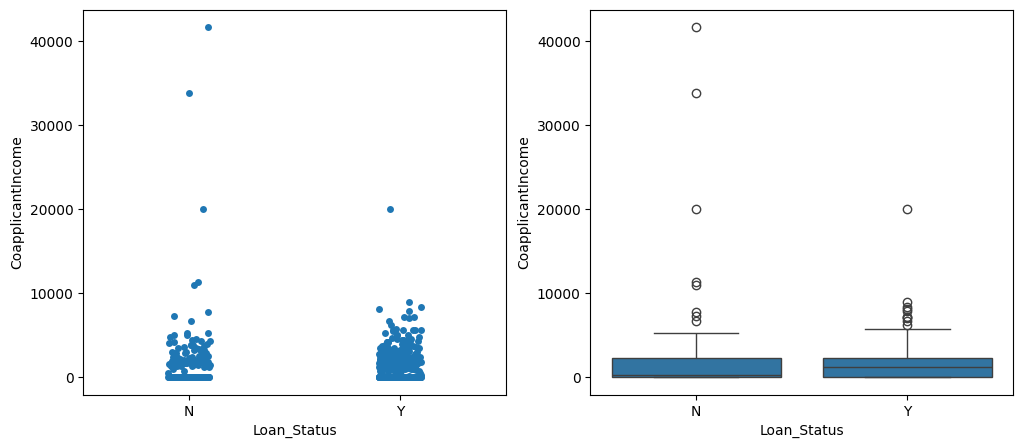

In [ ]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
sns.stripplot(data=df, x='Loan_Status', y='CoapplicantIncome')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Loan_Status', y='CoapplicantIncome')

**Observation:**

Customers with higher income co-applicant higher chances to loan approvel

**Decision:**

Consider scaling and log transformation before modeling

<Axes: xlabel='Loan_Status', ylabel='LoanAmount'>

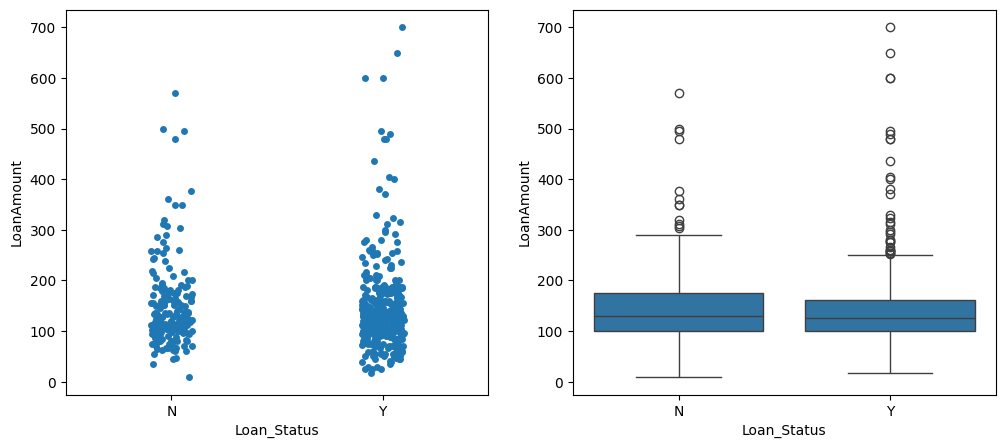

In [ ]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
sns.stripplot(data=df, x='Loan_Status', y='LoanAmount')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Loan_Status', y='LoanAmount')

**Decision:**

Consider scaling and log transformation before modeling

<Axes: xlabel='Loan_Status', ylabel='Loan_Amount_Term'>

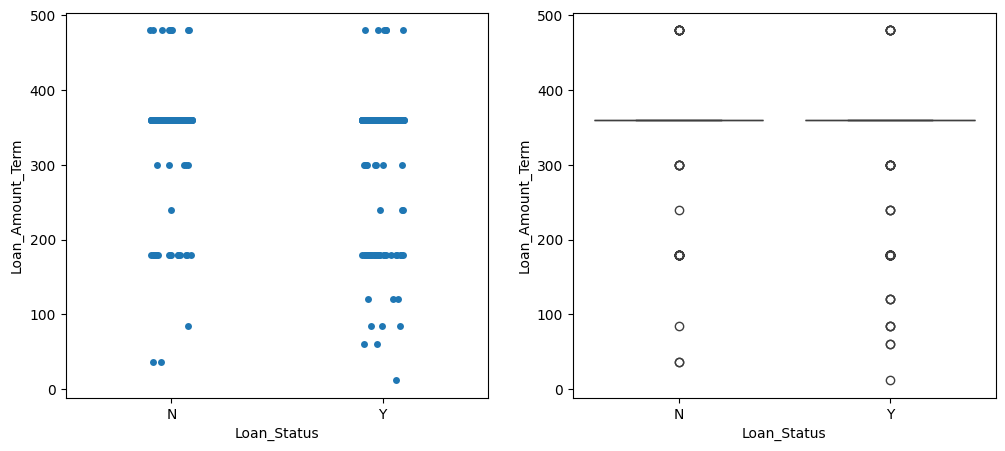

In [ ]:
plt.figure(figsize = (12,5))

plt.subplot(1,2,1)
sns.stripplot(data=df, x='Loan_Status', y='Loan_Amount_Term')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Loan_Status', y='Loan_Amount_Term')

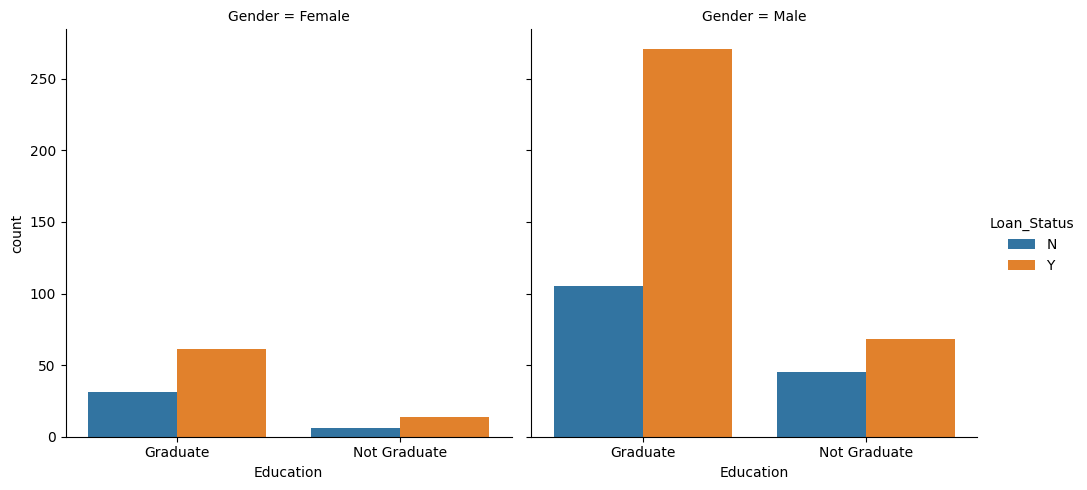

In [ ]:
sns.catplot(
    data=df,
    x='Education',
    hue='Loan_Status',
    col='Gender',
    kind='count'
)

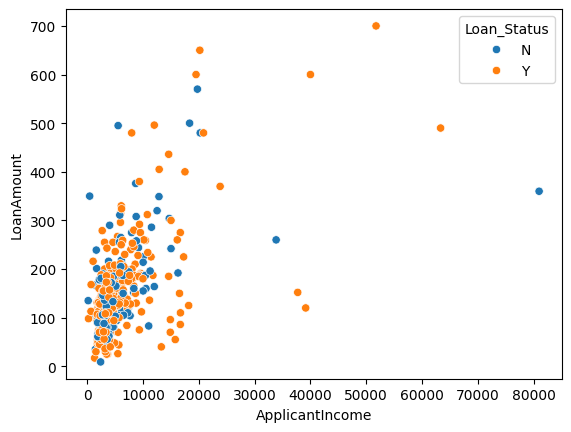

In [ ]:
sns.scatterplot(
    data=df,
    x='ApplicantIncome',
    y='LoanAmount',
    hue='Loan_Status'
)

plt.show()

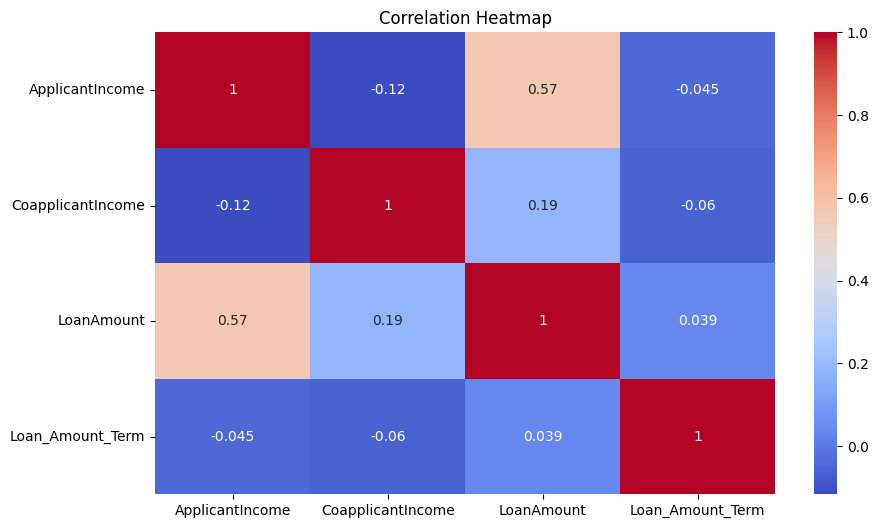

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

# Correlation Insights

1. Credit_History appears strongly related to loan approval.
2. ApplicantIncome and LoanAmount exhibit a positive relationship.
3. No severe multicollinearity is observed.

# Key Findings

1. Several columns contain missing values.
2. ApplicantIncome, CoapplicantIncome and LoanAmount are positively skewed.
3. Credit_History appears to be the strongest predictor of loan approval.
4. Moderate class imbalance exists.
5. Property_Area and Education show meaningful relationships with loan approval.
6. Multiple feature engineering opportunities were identified.

# Preprocessing Decisions

Based on EDA findings, the following preprocessing steps will be implemented:

1. Impute missing numerical values using median.
2. Impute missing categorical values using mode.
3. Create TotalIncome feature.
4. Create LoanIncomeRatio feature.
5. Apply log transformation to skewed numerical variables.
6. Encode categorical variables.
7. Scale numerical variables.
8. Build a reusable preprocessing pipeline using sklearn Pipeline and ColumnTransformer.